In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("messy_dataset.csv")

print("Original Data:")
print(df)
print(df.info())

Original Data:
     ID     Name           Age Country               Salary   Join Date
0   1.0    Alice            25      NZ                55000  15/01/2020
1   2.0      Bob           NaN      NZ                60000  20/02/2020
2   2.0      Bob            30      NZ                  NaN  20/02/2020
3   4.0  Charlie            35     AUS                72000         NaN
4   5.0    David  thirty-eight      NZ                68000   1/11/2019
5   NaN      Eve            29      AU                59000  2019-13-01
6   7.0      NaN            40      NZ  sixty five thousand  30/05/2018
7   8.0    Grace            22     NaN                64000  25/07/2021
8   9.0    Heidi           NaN     AUS                  NaN  25/07/2021
9  10.0     Ivan            27      NZ                58000  15/03/2019
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID     

In [12]:
# STEP 1: Remove duplicates

df = df.drop_duplicates()

In [13]:
# STEP 2: Fix missing IDs

df['ID'] = pd.to_numeric(df['ID'], errors='coerce')
df['ID'] = df['ID'].fillna(method='ffill')

/tmp/ipykernel_17555/4074098752.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['ID'] = df['ID'].fillna(method='ffill')


In [14]:
# STEP 3: Clean Age column

# Convert text to numbers
df['Age'] = df['Age'].replace({
    'thirty-eight': 38
})

df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [15]:
# STEP 4: Clean Salary column

df['Salary'] = df['Salary'].replace({
    'sixty five thousand': 65000
})

df['Salary'] = pd.to_numeric(df['Salary'], errors='coerce')
df['Salary'] = df['Salary'].fillna(df['Salary'].mean())

In [16]:
# STEP 5: Clean Country

df['Country'] = df['Country'].replace({
    'AU': 'AUS'
})

df['Country'] = df['Country'].fillna('NZ')

In [17]:
# STEP 6: Clean Name

df['Name'] = df['Name'].fillna('Unknown')

In [18]:
# STEP 7: Fix Join Date

df['Join Date'] = pd.to_datetime(df['Join Date'], errors='coerce')
df['Join Date'] = df['Join Date'].fillna(method='ffill')

/tmp/ipykernel_17555/2635333282.py:3: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Join Date'] = pd.to_datetime(df['Join Date'], errors='coerce')
/tmp/ipykernel_17555/2635333282.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Join Date'] = df['Join Date'].fillna(method='ffill')


In [19]:
print("\nCleaned Data:")
print(df)
print(df.info())


Cleaned Data:
     ID     Name    Age Country   Salary  Join Date
0   1.0    Alice  25.00      NZ  55000.0 2020-01-15
1   2.0      Bob  30.75      NZ  60000.0 2020-02-20
2   2.0      Bob  30.00      NZ  62625.0 2020-02-20
3   4.0  Charlie  35.00     AUS  72000.0 2020-02-20
4   5.0    David  38.00      NZ  68000.0 2019-11-01
5   5.0      Eve  29.00     AUS  59000.0 2019-11-01
6   7.0  Unknown  40.00      NZ  65000.0 2018-05-30
7   8.0    Grace  22.00      NZ  64000.0 2021-07-25
8   9.0    Heidi  30.75     AUS  62625.0 2021-07-25
9  10.0     Ivan  27.00      NZ  58000.0 2019-03-15
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   ID         10 non-null     float64       
 1   Name       10 non-null     object        
 2   Age        10 non-null     float64       
 3   Country    10 non-null     object        
 4   Salary     10 non-null   

CORRELATION HEATMAP (PEARSON)

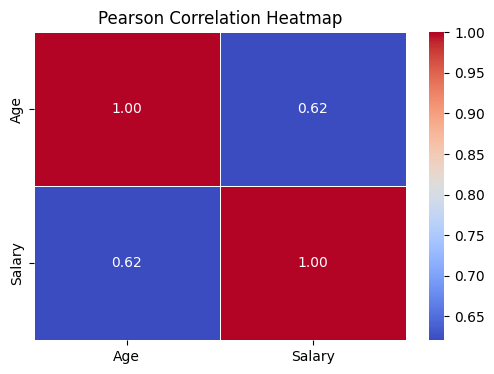

In [27]:
# Select numeric columns
numeric_df = df[['Age', 'Salary']]

# Correlation
corr = numeric_df.corr(method='pearson')

plt.figure(figsize=(6,4))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Pearson Correlation Heatmap")
plt.show()

VISUALIZATION

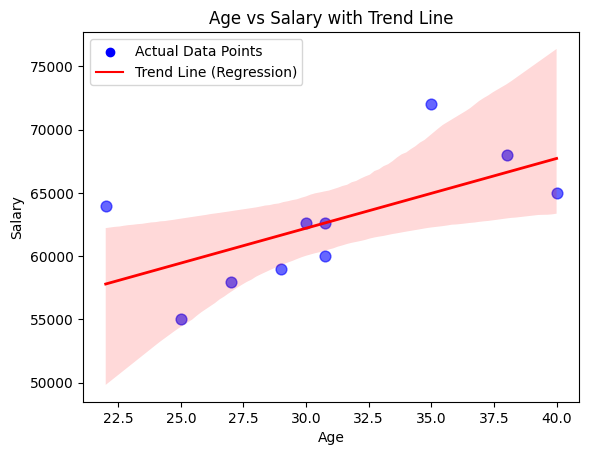

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(
    x='Age',
    y='Salary',
    data=df,
    scatter_kws={'color': 'blue', 'alpha': 0.6, 's': 60},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Age vs Salary with Trend Line")

# Custom legend
plt.scatter([], [], color='blue', label='Actual Data Points')
plt.plot([], [], color='red', label='Trend Line (Regression)')

plt.legend()

plt.show()

OUTLIER DETECTION

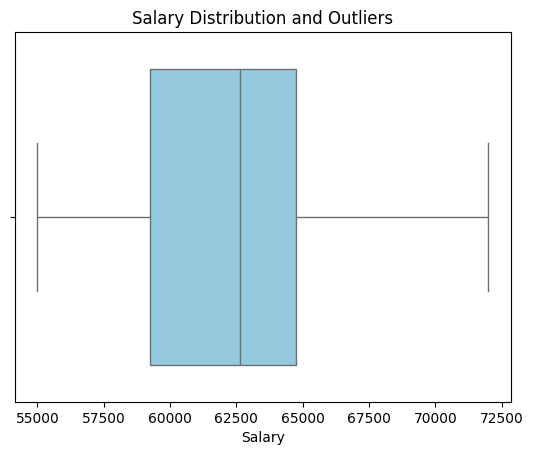

In [29]:
sns.boxplot(x=df['Salary'], color='skyblue')

plt.title("Salary Distribution and Outliers")
plt.xlabel("Salary")

plt.show()

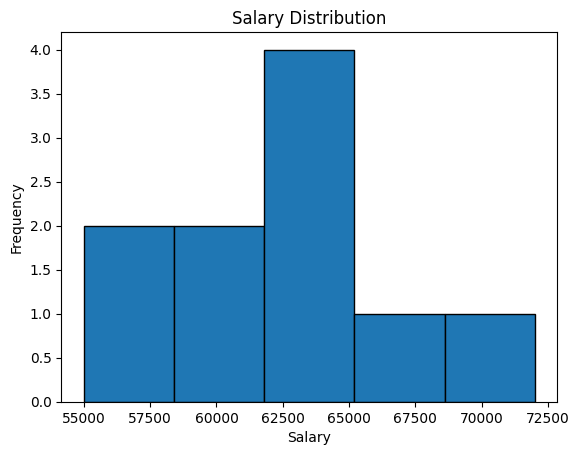

In [33]:
plt.hist(df['Salary'], bins=5, edgecolor='black')

plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")

plt.show()

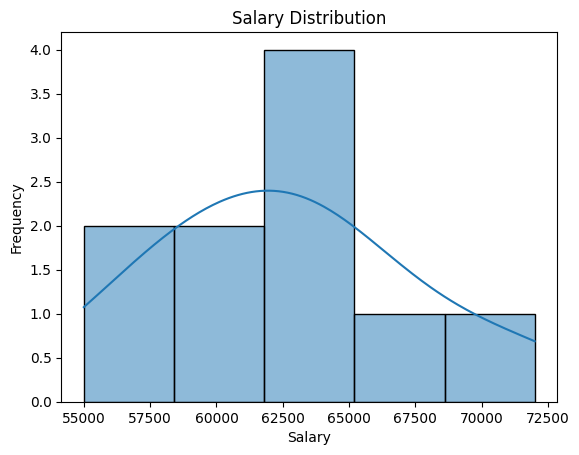

In [34]:
import seaborn as sns

sns.histplot(df['Salary'], bins=5, kde=True)

plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")

plt.show()

Z-score method

In [32]:
from scipy import stats

z_scores = np.abs(stats.zscore(df[['Age','Salary']]))
outliers = (z_scores > 3)

print("Outliers:\n", df[outliers.any(axis=1)])

Outliers:
 Empty DataFrame
Columns: [ID, Name, Age, Country, Salary, Join Date]
Index: []
